# BKK_Rain_V2 — same features, honest labels

`BKK_Rain_V1` reports ROC-AUC 0.925 at 1 h. That number is measured against
`OM_BKK_DATA.precipitation`, which is **ECMWF model output** — a forecast, and one that is
also the source of the model's own `precipitation*` features. The model is largely being
graded on how well it reproduces a smooth NWP field. Scored against an independent
observation it fell to ROC ≈ 0.72.

V2 changes three things and nothing else:

| | V1 | V2 |
|---|---|---|
| label source | Open-Meteo `precipitation` (ECMWF forecast) | **`IMERG_BKK_DATA`** (satellite observation) |
| rain threshold | 0.1 mm | **0.1 mm and 1.0 mm**, both built, both scored |
| target window | 1, 2, 3, 6 h | **1, 3, 6 h** |
| probabilities | raw | **raw and isotonic-calibrated**, both kept |
| evaluation | one chronological 70/15/15 split | **leave-one-year-out CV**, full out-of-fold coverage |

Features, hyperparameters and row filters are copied verbatim from V1.

Three prior findings drive these choices:

1. **Labels.** Open-Meteo agrees with the TMD gauge at CSI 0.146 / FAR 0.840 — the worst of
   the three available records — and its errors are timing-structured, matching ECMWF's
   known bias. IMERG is an observation.
2. **Threshold.** Gauge~IMERG skill peaks at 1.0 mm (HSS 0.397) rather than 0.1 mm (0.305).
   0.1 mm labels trace amounts where the records are least comparable.
3. **Aggregation.** Gauge~IMERG CSI more than doubles from hourly to daily, so longer
   windows are better constrained. 1 h is kept only as a comparison point.

Two limits worth stating up front. IMERG cannot carry intensity — for gauge-hours above
10 mm it reports at least half the gauge amount only 2.9 % of the time — so this is a
rain / no-rain model and can never become a heavy-rain warning. And IMERG's ~11 km cell
measures area rain while a gauge measures a point; the two are different quantities, not
competing measurements of one.

In [1]:
import gc
import json
import os
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Configuration

In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

PRECOMPUTE_TABLE_NAME = '"OM_BKK_DATA_PRECOMPUTE"'
IMERG_TABLE_NAME = '"IMERG_BKK_DATA"'
PROJECT_ROOT = Path.cwd()
V1_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_bkk_rain_any_v1"
OUTPUT_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_bkk_rain_v2_imerg"

HORIZONS = [1, 3, 6]
RAIN_THRESHOLDS_MM = [0.1, 1.0]
MAX_LEAD = max(HORIZONS)
MODEL_PLAN = {1: "lightgbm", 3: "hist_gradient_boosting", 6: "hist_gradient_boosting"}
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.05, 0.96, 0.05)
RANDOM_STATE = 42
PURGE_HOURS = 24
MIN_FOLD_ROWS = 50_000

# Share of each fold's training rows held back to fit the isotonic calibrator. The V1
# LightGBM models carry scale_pos_weight, which inflates probabilities; on TMD_BKK_V1 that
# drove Brier skill to -1.03 (worse than predicting the base rate). At a 1.0 mm threshold the
# positive class is rarer still, so calibration is fitted here rather than bolted on later.
CALIBRATION_FRACTION = 0.12

# V1's own test window. The V1-vs-V2 comparison in section 8 is restricted to it so that
# both models are strictly out-of-sample on the same rows.
V1_META = json.loads((V1_DIR / "bkk_rain_v1_metadata.json").read_text(encoding="utf-8"))
V1_TEST_START = pd.Timestamp(V1_META["validation_end_exclusive"])
print(f"V1 test window starts : {V1_TEST_START}")
print(f"Targets               : {len(HORIZONS) * len(RAIN_THRESHOLDS_MM)} "
      f"({HORIZONS} h x {RAIN_THRESHOLDS_MM} mm)")

V1 test window starts : 2025-10-19 01:00:00
Targets               : 6 ([1, 3, 6] h x [0.1, 1.0] mm)


## 2. Features — unchanged from V1

`precipitation` and its lags stay in. They are ECMWF's forecast of rain, which is a
legitimate *predictor*; the change in V2 is that it is no longer also the answer key.

In [3]:
BASELINE_FEATURE_COLUMNS = [
    "temperature_2m", "relative_humidity_2m", "pressure_msl", "surface_pressure",
    "dew_point_2m", "precipitation", "cloud_cover", "wind_speed_10m",
    "wind_direction_10m", "temperature_dew_point_spread", "pressure_msl_change_3h",
    "pressure_msl_change_6h", "precipitation_lag_1h", "precipitation_lag_2h",
    "precipitation_lag_3h", "precipitation_lag_6h", "precipitation_sum_past_3h",
    "precipitation_sum_past_6h", "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "cloud_cover_lag_1h", "cloud_cover_lag_3h", "cloud_cover_lag_6h",
    "humidity_lag_1h", "humidity_lag_3h", "humidity_lag_6h",
    "wind_speed_lag_1h", "wind_speed_lag_3h", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "grid_row", "grid_column", "latitude", "longitude",
]

NEIGHBOR_FEATURE_COLUMNS = [
    "neighbor_count", "neighbor_precipitation_mean", "neighbor_precipitation_max",
    "neighbor_precipitation_sum", "neighbor_rain_count", "neighbor_rain_rate",
    "neighbor_cloud_cover_mean", "neighbor_cloud_cover_max", "neighbor_relative_humidity_mean",
    "neighbor_relative_humidity_max", "neighbor_pressure_msl_mean", "neighbor_pressure_msl_min",
    "neighbor_pressure_msl_max", "neighbor_temperature_2m_mean", "neighbor_dew_point_2m_mean",
    "neighbor_temperature_dew_point_spread_mean", "neighbor_wind_speed_10m_mean",
    "neighbor_wind_speed_10m_max", "row_minus_precipitation_mean", "row_plus_precipitation_mean",
    "column_minus_precipitation_mean", "column_plus_precipitation_mean", "row_minus_cloud_cover_mean",
    "row_plus_cloud_cover_mean", "column_minus_cloud_cover_mean", "column_plus_cloud_cover_mean",
    "neighbor_precipitation_mean_minus_center", "neighbor_cloud_cover_mean_minus_center",
    "neighbor_relative_humidity_mean_minus_center", "center_pressure_msl_minus_neighbor_mean",
]

FEATURE_COLUMNS = BASELINE_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS
print(f"Features: {len(FEATURE_COLUMNS)} (identical to V1)")

Features: 66 (identical to V1)


## 3. Load features and future IMERG rainfall

The IMERG side needs care. `LEAD(precipitation_mm, k)` walks *rows*, not clock hours, and
the `is_complete_hour` filter removes rows — so a naive LEAD would happily reach across a
gap and label an hour from whatever survived. Each lead therefore carries its own
timestamp, and is nulled unless it lands exactly `k` hours ahead. This is the same failure
the TMD notebook avoided by reindexing onto a gap-free panel.

In [4]:
ROW_FILTER_SQL = '''
      om.pressure_msl_change_6h IS NOT NULL
      AND om.precipitation_lag_6h IS NOT NULL
      AND om.precipitation_sum_past_24h IS NOT NULL
      AND om.cloud_cover_lag_6h IS NOT NULL
      AND om.humidity_lag_6h IS NOT NULL
      AND om.wind_speed_lag_3h IS NOT NULL
      AND om.neighbor_count > 0
'''


def connect():
    return psycopg2.connect(**DB_CONFIG)


def build_query():
    feature_sql = ",\n        ".join(
        f"COALESCE(om.{c}::real, 'NaN'::real) AS {c}" for c in FEATURE_COLUMNS)
    lead_sql = ",\n            ".join(
        f"LEAD(precipitation_mm, {k}) OVER w AS p{k}, "
        f"LEAD(local_observation_time, {k}) OVER w AS t{k}"
        for k in range(1, MAX_LEAD + 1))
    # a lead only counts if its timestamp is exactly k hours after the anchor
    guarded_sql = ",\n        ".join(
        f"CASE WHEN im.t{k} = im.t_local + interval '{k} hour' "
        f"THEN im.p{k}::real ELSE 'NaN'::real END AS p{k}"
        for k in range(1, MAX_LEAD + 1))
    return f'''
    WITH im AS (
        SELECT grid_number, local_observation_time AS t_local,
            {lead_sql}
        FROM {IMERG_TABLE_NAME}
        WHERE is_complete_hour
        WINDOW w AS (PARTITION BY grid_number ORDER BY local_observation_time)
    )
    SELECT om.grid_number, om.local_forecast_time,
        {feature_sql},
        {guarded_sql}
    FROM {PRECOMPUTE_TABLE_NAME} om
    JOIN im ON im.grid_number = om.grid_number AND im.t_local = om.local_forecast_time
    WHERE {ROW_FILTER_SQL}
    ORDER BY om.local_forecast_time, om.grid_number
    '''


def read_training_data(batch_size=200_000):
    query = build_query()
    n_feat = len(FEATURE_COLUMNS)
    with connect() as conn:
        with conn.cursor() as cur:
            cur.execute(f'''
                SELECT count(*) FROM {PRECOMPUTE_TABLE_NAME} om
                JOIN (SELECT grid_number, local_observation_time AS t_local
                      FROM {IMERG_TABLE_NAME} WHERE is_complete_hour) im
                  ON im.grid_number = om.grid_number AND im.t_local = om.local_forecast_time
                WHERE {ROW_FILTER_SQL}''')
            n_rows = cur.fetchone()[0]
        print(f"Allocating {n_rows:,} x {n_feat} float32 "
              f"({n_rows * n_feat * 4 / 1e9:.2f} GB) + {MAX_LEAD} lead columns")

        x = np.empty((n_rows, n_feat), dtype="float32")
        future = np.empty((n_rows, MAX_LEAD), dtype="float32")
        t = np.empty(n_rows, dtype="datetime64[s]")
        unit = np.empty(n_rows, dtype="int32")
        filled = 0
        with conn.cursor(name="bkk_v2_stream") as cur:
            cur.itersize = batch_size
            cur.execute(query)
            while filled < n_rows:
                batch = cur.fetchmany(batch_size)
                if not batch:
                    break
                block = np.asarray(batch, dtype="object")
                take = len(batch)
                unit[filled:filled + take] = block[:, 0].astype("int32")
                t[filled:filled + take] = block[:, 1].astype("datetime64[s]")
                x[filled:filled + take] = block[:, 2:2 + n_feat].astype("float32")
                future[filled:filled + take] = block[:, 2 + n_feat:].astype("float32")
                filled += take
                print(f"  {filled:,} / {n_rows:,}", end="\r", flush=True)
        print()
    return x[:filled], future[:filled], t[:filled], unit[:filled]


started = time.time()
x_all, future_rain, forecast_time, unit_id = read_training_data()
print(f"Loaded {x_all.shape[0]:,} rows in {(time.time()-started)/60:.1f} min")
print(f"{forecast_time.min()} .. {forecast_time.max()}   cells: {np.unique(unit_id).size}")
print(f"\nfuture IMERG hours present (share non-NaN, after the gap guard):")
print(pd.Series(1 - np.isnan(future_rain).mean(axis=0),
                index=[f"+{k}h" for k in range(1, MAX_LEAD + 1)]).to_string())

Allocating 2,453,696 x 66 float32 (0.65 GB) + 6 lead columns



Loaded 2,453,696 rows in 3.1 min
2021-07-20T07:00:00 .. 2026-07-19T23:00:00   cells: 56

future IMERG hours present (share non-NaN, after the gap guard):
+1h   1.0000
+2h   1.0000
+3h   0.9999
+4h   0.9999
+5h   0.9999
+6h   0.9999


## 4. Build the targets

`rain_any_next_Nh` at threshold X: did IMERG record at least X mm in any of the next N
hours. A row is dropped if any hour of its longest window is missing, so every target is
built on exactly the same rows and the numbers are directly comparable.

In [5]:
complete = ~np.isnan(future_rain[:, :MAX_LEAD]).any(axis=1)
print(f"rows with a complete {MAX_LEAD}h future window: {complete.sum():,} "
      f"({complete.mean():.1%})")

x_all = np.ascontiguousarray(x_all[complete])
future_rain = future_rain[complete]
forecast_time = forecast_time[complete]
unit_id = unit_id[complete]

TARGETS = [(h, thr) for thr in RAIN_THRESHOLDS_MM for h in HORIZONS]
TARGET_NAMES = [f"h{h}_{thr}mm" for h, thr in TARGETS]
y_all = np.empty((x_all.shape[0], len(TARGETS)), dtype="int8")
for i, (h, thr) in enumerate(TARGETS):
    y_all[:, i] = (future_rain[:, :h].max(axis=1) >= thr).astype("int8")

del future_rain
gc.collect()

balance = pd.DataFrame({
    "target": TARGET_NAMES,
    "horizon_h": [h for h, _ in TARGETS],
    "threshold_mm": [thr for _, thr in TARGETS],
    "base_rate": y_all.mean(axis=0),
    "positives": y_all.sum(axis=0),
})
display(balance)
print("For reference, V1's Open-Meteo-labelled base rates were 0.221 (1h) and 0.439 (6h).")

rows with a complete 6h future window: 2,453,360 (100.0%)


,target,horizon_h,threshold_mm,base_rate,positives
0,h1_0.1mm,1,0.1000,0.1779,436338
1,h3_0.1mm,3,0.1000,0.2747,673854
2,h6_0.1mm,6,0.1000,0.3730,915179
3,h1_1.0mm,1,1.0000,0.0478,117294
4,h3_1.0mm,3,1.0000,0.0807,198066
5,h6_1.0mm,6,1.0000,0.1241,304463


For reference, V1's Open-Meteo-labelled base rates were 0.221 (1h) and 0.439 (6h).


In [6]:
stamps = pd.to_datetime(forecast_time)
year_key = stamps.year.to_numpy()
month_key = pd.PeriodIndex(stamps, freq="M").astype(str).to_numpy()
unique_months = sorted(pd.unique(month_key))
PURGE = np.timedelta64(PURGE_HOURS, "h")


def purged_train_mask(test_mask, times=forecast_time, purge=PURGE):
    """Training rows: not held out, and not within `purge` of any held-out timestamp."""
    test_times = np.unique(times[test_mask])
    position = np.searchsorted(test_times, times)
    left = test_times[np.clip(position - 1, 0, len(test_times) - 1)]
    right = test_times[np.clip(position, 0, len(test_times) - 1)]
    distance = np.minimum(np.abs(times - left), np.abs(times - right))
    return ~test_mask & (distance > purge)


YEAR_FOLDS = [int(y) for y in np.unique(year_key) if (year_key == y).sum() >= MIN_FOLD_ROWS]
fold_table = pd.DataFrame([{
    "fold": str(y), "test_rows": int((year_key == y).sum()),
    "train_rows": int(purged_train_mask(year_key == y).sum()),
    "base_rate_h1_0.1mm": float(y_all[year_key == y, TARGET_NAMES.index("h1_0.1mm")].mean()),
    "base_rate_h6_1.0mm": float(y_all[year_key == y, TARGET_NAMES.index("h6_1.0mm")].mean()),
} for y in YEAR_FOLDS])
display(fold_table)

,fold,test_rows,train_rows,base_rate_h1_0.1mm,base_rate_h6_1.0mm
0,2021,221368,2230648,0.2281,0.1781
1,2022,490560,1960112,0.2189,0.1483
2,2023,490560,1960112,0.1536,0.1013
3,2024,491904,1958768,0.1652,0.1173
4,2025,490560,1960112,0.2019,0.1319
5,2026,268408,2183608,0.0851,0.0753


## 5. Leave-one-year-out CV with isotonic calibration

`BKK_RAIN_CV1` established that holding out a year costs ~0.002 ROC-AUC versus holding out
a season, so a year-blocked fold is a fair test. Within each fold a slice of the training
rows is held back to fit the calibrator, so the isotonic map never sees the test year.

In [7]:
def fit_predict_calibrated(x_train, y_train, x_test, model_name, rng):
    """Fit the model, then an isotonic calibrator on a held-back slice of the training rows."""
    n = len(y_train)
    calib_size = int(n * CALIBRATION_FRACTION)
    shuffled = rng.permutation(n)
    calib_index, fit_index = shuffled[:calib_size], shuffled[calib_size:]

    if model_name == "lightgbm":
        scale_pos_weight = float((y_train[fit_index] == 0).sum()
                                 / max((y_train[fit_index] == 1).sum(), 1))
        model = LGBMClassifier(
            objective="binary", n_estimators=500, learning_rate=0.04, num_leaves=63,
            min_child_samples=80, subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
            n_jobs=-1, verbose=-1,
        )
    else:
        model = HistGradientBoostingClassifier(
            learning_rate=0.06, max_iter=250, max_leaf_nodes=31,
            l2_regularization=0.05, random_state=RANDOM_STATE, early_stopping=False,
        )
    model.fit(x_train[fit_index], y_train[fit_index])

    raw_calib = model.predict_proba(x_train[calib_index])[:, 1]
    isotonic = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
    isotonic.fit(raw_calib, y_train[calib_index])

    raw_test = model.predict_proba(x_test)[:, 1].astype("float32")
    calibrated_test = isotonic.predict(raw_test).astype("float32")
    del model, isotonic
    gc.collect()
    return raw_test, calibrated_test


rng = np.random.default_rng(RANDOM_STATE)
oof_raw = np.full((x_all.shape[0], len(TARGETS)), np.nan, dtype="float32")
oof_cal = np.full((x_all.shape[0], len(TARGETS)), np.nan, dtype="float32")
fit_log = []
cv_started = time.time()

for year in YEAR_FOLDS:
    test_mask = year_key == year
    train_mask = purged_train_mask(test_mask)
    x_train, x_test = x_all[train_mask], x_all[test_mask]
    print(f"\n=== fold {year}: test {test_mask.sum():,}  train {train_mask.sum():,} ===",
          flush=True)
    for i, (horizon, threshold) in enumerate(TARGETS):
        model_name = MODEL_PLAN[horizon]
        started = time.time()
        raw, calibrated = fit_predict_calibrated(
            x_train, y_all[train_mask, i], x_test, model_name, rng)
        oof_raw[test_mask, i] = raw
        oof_cal[test_mask, i] = calibrated
        elapsed = time.time() - started
        fit_log.append({"fold": str(year), "target": TARGET_NAMES[i], "horizon_h": horizon,
                        "threshold_mm": threshold, "model": model_name,
                        "train_rows": int(train_mask.sum()), "fit_seconds": elapsed})
        print(f"  {TARGET_NAMES[i]:14} {model_name:22} {elapsed/60:.1f} min", flush=True)
    del x_train, x_test
    gc.collect()

fit_log = pd.DataFrame(fit_log)
print(f"\nCV finished in {(time.time()-cv_started)/60:.1f} min; "
      f"coverage {np.isfinite(oof_raw).all(axis=1).mean():.4f}")
display(fit_log.groupby("target")["fit_seconds"].agg(["count", "mean", "sum"]))


=== fold 2021: test 221,368  train 2,230,648 ===


  h1_0.1mm       lightgbm               1.0 min


  h3_0.1mm       hist_gradient_boosting 1.0 min


  h6_0.1mm       hist_gradient_boosting 2.7 min


  h1_1.0mm       lightgbm               2.7 min


...

  h1_1.0mm       lightgbm               0.8 min


  h3_1.0mm       hist_gradient_boosting 0.7 min


  h6_1.0mm       hist_gradient_boosting 0.8 min



CV finished in 43.4 min; coverage 1.0000


,count,mean,sum
target,,,
h1_0.1mm,6,83.9540,503.7239
h1_1.0mm,6,86.9448,521.6689
h3_0.1mm,6,83.9483,503.6895
h3_1.0mm,6,47.6183,285.7096
h6_0.1mm,6,82.5926,495.5556
h6_1.0mm,6,48.1096,288.6576


## 6. Scoring

The operating threshold for each target is chosen **leave-one-year-out**: the F1-optimal
threshold is found on the out-of-fold predictions of every *other* year and then applied to
the year being scored. Picking it on the same rows it is scored on would be optimistic.

In [8]:
def pick_threshold(probabilities, y_true):
    best_f1, best_threshold = -1.0, 0.5
    for candidate in PROBABILITY_THRESHOLDS_TO_TEST:
        score = f1_score(y_true, (probabilities >= candidate).astype("int8"), zero_division=0)
        if score > best_f1:
            best_f1, best_threshold = score, float(candidate)
    return best_threshold


def score_target(index, probabilities, label):
    y_true = y_all[:, index]
    valid = np.isfinite(probabilities)
    predictions = np.zeros(len(y_true), dtype="int8")
    chosen = {}
    for year in YEAR_FOLDS:                      # honest, leave-one-year-out threshold
        this_year = (year_key == year) & valid
        others = valid & ~(year_key == year)
        threshold = pick_threshold(probabilities[others], y_true[others])
        chosen[year] = threshold
        predictions[this_year] = (probabilities[this_year] >= threshold).astype("int8")

    base = float(y_true[valid].mean())
    pr = float(average_precision_score(y_true[valid], probabilities[valid]))
    brier = float(brier_score_loss(y_true[valid], probabilities[valid]))
    climatology = base * (1 - base)
    return {
        "target": TARGET_NAMES[index], "horizon_h": TARGETS[index][0],
        "threshold_mm": TARGETS[index][1], "probabilities": label,
        "rows": int(valid.sum()), "base_rate": base,
        "roc_auc": float(roc_auc_score(y_true[valid], probabilities[valid])),
        "pr_auc": pr, "pr_auc_lift": pr / base,
        "precision": float(precision_score(y_true[valid], predictions[valid], zero_division=0)),
        "recall": float(recall_score(y_true[valid], predictions[valid], zero_division=0)),
        "f1": float(f1_score(y_true[valid], predictions[valid], zero_division=0)),
        "brier_score": brier, "brier_climatology": climatology,
        "brier_skill": 1 - brier / climatology,
        "threshold_min": min(chosen.values()), "threshold_max": max(chosen.values()),
    }


results = pd.DataFrame(
    [score_target(i, oof_raw[:, i], "raw") for i in range(len(TARGETS))]
    + [score_target(i, oof_cal[:, i], "calibrated") for i in range(len(TARGETS))])

print("=== V2 out-of-fold results, IMERG labels ===")
display(results.sort_values(["threshold_mm", "horizon_h", "probabilities"]))

print("\n=== what calibration bought ===")
pivot = results.pivot_table(index=["threshold_mm", "horizon_h"], columns="probabilities",
                            values=["brier_skill", "roc_auc", "f1"])
display(pivot)

=== V2 out-of-fold results, IMERG labels ===


,target,horizon_h,threshold_mm,probabilities,rows,base_rate,roc_auc,pr_auc,pr_auc_lift,precision,recall,f1,brier_score,brier_climatology,brier_skill,threshold_min,threshold_max
6,h1_0.1mm,1,0.1000,calibrated,2453360,0.1779,0.8500,0.5506,3.0957,0.4501,0.6869,0.5439,0.1089,0.1462,0.2554,0.2500,0.2500
0,h1_0.1mm,1,0.1000,raw,2453360,0.1779,0.8506,0.5534,3.1118,0.4514,0.6884,0.5453,0.1563,0.1462,-0.0690,0.6000,0.6000
7,h3_0.1mm,3,0.1000,calibrated,2453360,0.2747,0.8522,0.6753,2.4585,0.5504,0.7816,0.6460,0.1357,0.1992,0.3186,0.3000,0.3000
1,h3_0.1mm,3,0.1000,raw,2453360,0.2747,0.8521,0.6758,2.4605,0.5504,0.7816,0.6459,0.1354,0.1992,0.3205,0.3000,0.3000
8,h6_0.1mm,6,0.1000,calibrated,2453360,0.3730,0.8616,0.7739,2.0746,0.6544,0.8188,0.7274,0.1462,0.2339,0.3747,0.3500,0.4000
2,h6_0.1mm,6,0.1000,raw,2453360,0.3730,0.8616,0.7742,2.0755,0.6500,0.8299,0.7290,0.1459,0.2339,0.3761,0.3500,0.3500
9,h1_1.0mm,1,1.0000,calibrated,2453360,0.0478,0.8716,0.2707,5.6615,0.2705,0.4319,0.3326,0.0402,0.0455,0.1162,0.2000,0.2000
3,h1_1.0mm,1,1.0000,raw,2453360,0.0478,0.8721,0.2729,5.7076,0.2604,0.4577,0.3319,0.1232,0.0455,-1.7068,0.7500,0.7500
10,h3_1.0mm,3,1.0000,calibrated,2453360,0.0807,0.8590,0.3437,4.2576,0.3204,0.5172,0.3957,0.0625,0.0742,0.1578,0.2000,0.2000
4,h3_1.0mm,3,1.0000,raw,2453360,0.0807,0.8591,0.3444,4.2659,0.3228,0.5096,0.3953,0.0618,0.0742,0.1679,0.2000,0.2000



=== what calibration bought ===


brier_skill                 f1           roc_auc       
probabilities           calibrated     raw calibrated    raw calibrated    raw
threshold_mm horizon_h                                                        
0.1000       1              0.2554 -0.0690     0.5439 0.5453     0.8500 0.8506
             3              0.3186  0.3205     0.6460 0.6459     0.8522 0.8521
             6              0.3747  0.3761     0.7274 0.7290     0.8616 0.8616
1.0000       1              0.1162 -1.7068     0.3326 0.3319     0.8716 0.8721
             3              0.1578  0.1679     0.3957 0.3953     0.8590 0.8591
             6              0.1860  0.1942     0.4560 0.4552     0.8444 0.8444

## 7. Does 1.0 mm beat 0.1 mm, and do longer windows help?

Raw PR-AUC cannot be compared across targets with different base rates — its floor *is* the
base rate. `pr_auc_lift` (PR-AUC / base rate) is the comparable quantity.

In [9]:
best = results[results["probabilities"] == "calibrated"]
display(best.pivot_table(index="horizon_h", columns="threshold_mm",
                         values=["base_rate", "roc_auc", "pr_auc", "pr_auc_lift",
                                 "f1", "brier_skill"]))

base_rate        brier_skill            f1        pr_auc        pr_auc_lift        roc_auc       
threshold_mm    0.1000 1.0000      0.1000 1.0000 0.1000 1.0000 0.1000 1.0000      0.1000 1.0000  0.1000 1.0000
horizon_h                                                                                                     
1               0.1779 0.0478      0.2554 0.1162 0.5439 0.3326 0.5506 0.2707      3.0957 5.6615  0.8500 0.8716
3               0.2747 0.0807      0.3186 0.1578 0.6460 0.3957 0.6753 0.3437      2.4585 4.2576  0.8522 0.8590
6               0.3730 0.1241      0.3747 0.1860 0.7274 0.4560 0.7739 0.4154      2.0746 3.3477  0.8616 0.8444

## 8. V1 versus V2 on the same yardstick

`BKK_Rain_V1`'s saved models are scored on IMERG labels over **V1's own test window**, so
both models are strictly out-of-sample on identical rows. V1 predicts Open-Meteo rain;
the question is how well that ranking transfers to observed rain.

In [10]:
window = forecast_time >= np.datetime64(V1_TEST_START)
print(f"shared evaluation window: {V1_TEST_START} .. {forecast_time.max()} "
      f"({window.sum():,} rows)")

comparison = []
for horizon in HORIZONS:
    model_path = next(V1_DIR.glob(f"om_bkk_rain_any_v1_next_{horizon}h_*.joblib"), None)
    if model_path is None:
        print(f"no V1 model for {horizon}h, skipping")
        continue
    v1_model = joblib.load(model_path)
    v1_probabilities = v1_model.predict_proba(x_all[window])[:, 1]
    del v1_model
    gc.collect()

    for threshold_mm in RAIN_THRESHOLDS_MM:
        index = TARGET_NAMES.index(f"h{horizon}_{threshold_mm}mm")
        y_true = y_all[window, index]
        if y_true.min() == y_true.max():
            continue
        base = float(y_true.mean())
        for name, probabilities in [("V1_trained_on_open_meteo", v1_probabilities),
                                    ("V2_trained_on_imerg", oof_cal[window, index])]:
            pr = float(average_precision_score(y_true, probabilities))
            comparison.append({
                "horizon_h": horizon, "threshold_mm": threshold_mm, "model": name,
                "rows": int(window.sum()), "base_rate": base,
                "roc_auc": float(roc_auc_score(y_true, probabilities)),
                "pr_auc": pr, "pr_auc_lift": pr / base,
            })

comparison = pd.DataFrame(comparison)
print("\n=== both models graded on IMERG, V1's test window ===")
display(comparison.pivot_table(index=["threshold_mm", "horizon_h"], columns="model",
                               values=["roc_auc", "pr_auc_lift"]))

shared evaluation window: 2025-10-19 01:00:00 .. 2026-07-19T23:00:00 (367,808 rows)



=== both models graded on IMERG, V1's test window ===


pr_auc_lift                                      roc_auc                    
model                  V1_trained_on_open_meteo V2_trained_on_imerg V1_trained_on_open_meteo V2_trained_on_imerg
threshold_mm horizon_h                                                                                          
0.1000       1                           2.6658              3.3167                   0.7604              0.8280
             3                           2.3484              2.6800                   0.7687              0.8257
             6                           2.0599              2.2900                   0.7674              0.8299
1.0000       1                           3.9200              5.4716                   0.8128              0.8616
             3                           3.5971              4.6132                   0.8071              0.8491
             6                           2.9649              3.6300                   0.7926              0.8333

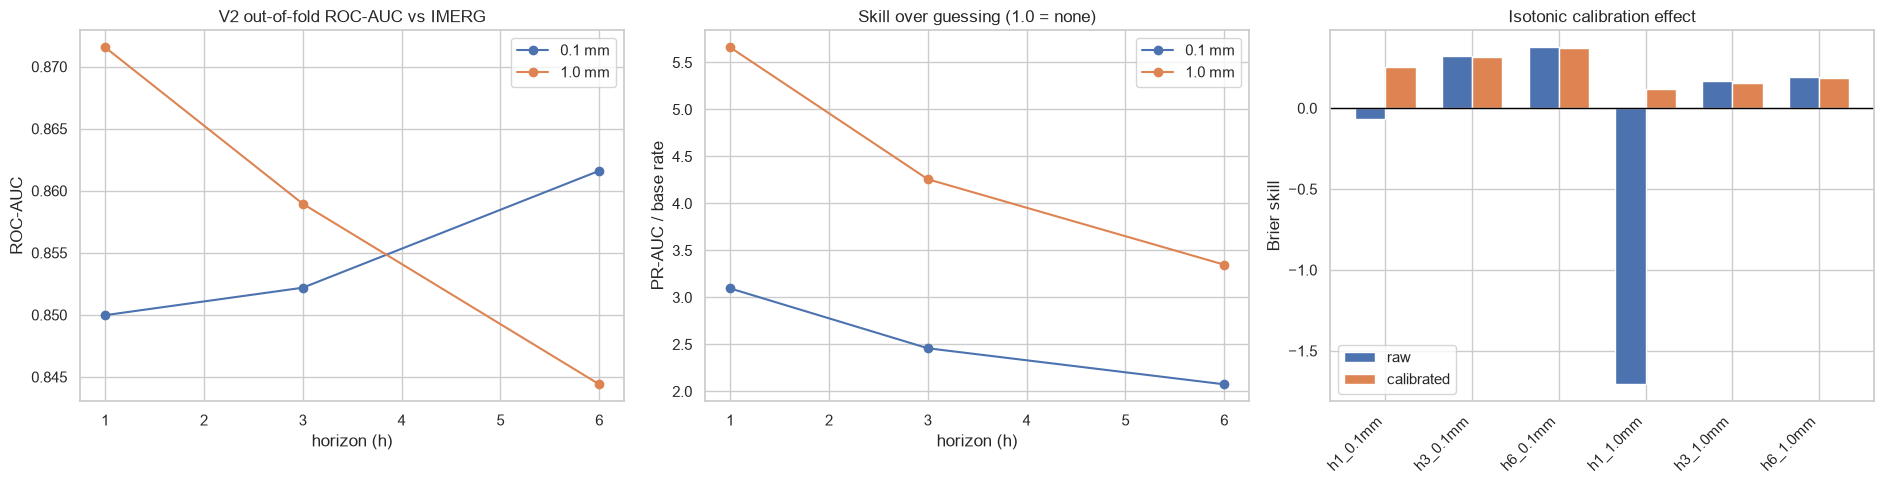

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

ax = axes[0]
for threshold_mm in RAIN_THRESHOLDS_MM:
    sub = best[best["threshold_mm"] == threshold_mm]
    ax.plot(sub["horizon_h"], sub["roc_auc"], marker="o", label=f"{threshold_mm} mm")
ax.set_xlabel("horizon (h)"); ax.set_ylabel("ROC-AUC")
ax.set_title("V2 out-of-fold ROC-AUC vs IMERG"); ax.legend()

ax = axes[1]
for threshold_mm in RAIN_THRESHOLDS_MM:
    sub = best[best["threshold_mm"] == threshold_mm]
    ax.plot(sub["horizon_h"], sub["pr_auc_lift"], marker="o", label=f"{threshold_mm} mm")
ax.set_xlabel("horizon (h)"); ax.set_ylabel("PR-AUC / base rate")
ax.set_title("Skill over guessing (1.0 = none)"); ax.legend()

ax = axes[2]
width = 0.35
raw = results[results["probabilities"] == "raw"].sort_values(["threshold_mm", "horizon_h"])
cal = results[results["probabilities"] == "calibrated"].sort_values(["threshold_mm", "horizon_h"])
positions = np.arange(len(raw))
ax.bar(positions - width / 2, raw["brier_skill"], width, label="raw")
ax.bar(positions + width / 2, cal["brier_skill"], width, label="calibrated")
ax.axhline(0, color="black", lw=1)
ax.set_xticks(positions); ax.set_xticklabels(raw["target"], rotation=45, ha="right")
ax.set_ylabel("Brier skill"); ax.set_title("Isotonic calibration effect"); ax.legend()

plt.tight_layout()
plt.show()

## 9. Save

In [12]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results.to_csv(OUTPUT_DIR / "v2_oof_results.csv", index=False)
balance.to_csv(OUTPUT_DIR / "v2_target_balance.csv", index=False)
fold_table.to_csv(OUTPUT_DIR / "v2_folds.csv", index=False)
fit_log.to_csv(OUTPUT_DIR / "v2_fit_log.csv", index=False)
comparison.to_csv(OUTPUT_DIR / "v2_vs_v1_on_imerg.csv", index=False)

metadata = {
    "purpose": "BKK_Rain_V1 features, retrained against IMERG observations instead of "
               "Open-Meteo forecast output; 0.1 mm and 1.0 mm thresholds; 1/3/6 h windows",
    "precompute_table": PRECOMPUTE_TABLE_NAME,
    "label_table": IMERG_TABLE_NAME,
    "label_source": "IMERG satellite observation (is_complete_hour only, gap-guarded leads)",
    "rows": int(x_all.shape[0]),
    "span": [str(forecast_time.min()), str(forecast_time.max())],
    "horizons": HORIZONS,
    "rain_thresholds_mm": RAIN_THRESHOLDS_MM,
    "model_plan": MODEL_PLAN,
    "calibration": f"isotonic, fitted on {CALIBRATION_FRACTION:.0%} of each fold's training rows",
    "cv": "leave-one-year-out",
    "year_folds": [str(y) for y in YEAR_FOLDS],
    "purge_hours": PURGE_HOURS,
    "threshold_selection": "F1-optimal on out-of-fold predictions of all other years",
    "oof_coverage": float(np.isfinite(oof_cal).all(axis=1).mean()),
    "results": results.to_dict(orient="records"),
    "v1_comparison": comparison.to_dict(orient="records"),
    "caveats": [
        "IMERG measures area rain over an ~11 km cell; a gauge measures a point. These are "
        "different quantities, so V2 predicts 'rain somewhere in the cell', not 'rain here'.",
        "IMERG cannot carry intensity - for gauge-hours above 10 mm it reports at least half "
        "the gauge amount only 2.9% of the time. This model can never become a heavy-rain warning.",
        "Everything after 2025-10-01 is provisional Late Run IMERG, whose POD is about 12% "
        "lower season-controlled; the last fold is affected.",
    ],
}
(OUTPUT_DIR / "v2_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print(f"Saved V2 results to {OUTPUT_DIR}")

Saved V2 results to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\om_bkk_rain_v2_imerg
